Este netbook realizara un Análisis Exploratorio de Datos (EDA) enfocado en la caracterización estructural del dataset, la evolucion y la identificación de comportamientos relevantes para guiar procesos posteriores de preprocesamiento y construcción de modelos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Configuración de visualización
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# 1. Configuración e ingesta de los datos

In [3]:
def cargar_dataframe():
    # Carga del dataset de homicidios con manejo de rutas y excepciones
    ruta = Path.cwd().parent / "data" / "raw" / "base_homicidios.csv"

    try:
        df = pd.read_csv(ruta)
        print(f"Carga exitosa del DataFrame:\n\n{df.shape[0]} filas.\n{df.shape[1]} columas")

        return df

    except FileNotFoundError:
        print(f"Error: No se encontro el archivo en {ruta.absolute()}")
        return None
    
    except Exception as e:
        print(f"Error inesperado: {e}")
        return None

df = cargar_dataframe()

Carga exitosa del DataFrame:

22092 filas.
6 columas


# 2. Inspección inicial:

El objetivo es entender que tipos de datos tenemos y detectar discrepancias inmediatas.

In [4]:
""" Vista rapida de las primeras 5 columas """
display(df.head(-5))

,iso_code,country,year,sex,age_group,homicide_rate
0,AFG,Afghanistan,2009,both,ALL,4.059550
1,AFG,Afghanistan,2010,both,ALL,3.475452
2,AFG,Afghanistan,2011,both,ALL,4.194535
3,AFG,Afghanistan,2012,both,ALL,6.374339
4,AFG,Afghanistan,2015,both,ALL,9.952186
...,...,...,...,...,...,...
22082,ZWE,Zimbabwe,2019,male,ALL,8.600883
22083,ZWE,Zimbabwe,2020,both,ALL,5.023543
22084,ZWE,Zimbabwe,2020,female,ALL,1.790027
22085,ZWE,Zimbabwe,2020,male,ALL,8.601756


In [5]:
""" Diagnostico de tipos y memoria """
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22092 entries, 0 to 22091
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   iso_code       22092 non-null  object 
 1   country        22092 non-null  object 
 2   year           22092 non-null  int64  
 3   sex            22092 non-null  object 
 4   age_group      22092 non-null  object 
 5   homicide_rate  22092 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 1.0+ MB


Observaciones de la inspeccion:

    - Fechas: La columna fecha se detecta como int64, no va a realizarse cambios devido a que solamente tiene el dato del año.
    - Es necesario verificar si el ID es úncio por hecho o por víctima.
    

# 3. Diagnóstico de calidad de datos

In [6]:
""" Análisis de los valores nulos """
nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df)) * 100
# Creacion del DataFrame de reporte
df_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje %': nulos_pct
    })

# Filtrado y ordenamiento
reporte_errores = df_nulos[df_nulos["Nulos"] > 0].sort_values(by='Porcentaje %', ascending=False)

# Salida por pantalla
print(f"Total de registro: {len(df)}")

if not reporte_errores.empty:
    print("Columnas que requieren atención imnediata (Nulos):")
    print(reporte_errores)
else:
    print("No se detectaron valores nulos en el dataset.")

Total de registro: 22092
No se detectaron valores nulos en el dataset.


In [7]:
""" Analisis de los valores duplicados """

duplicados = df.duplicated().sum()
print(f"Registro total de los duplicados {duplicados}")

Registro total de los duplicados 0


# 4. analisis estadistico y cardinal

In [9]:
# Estadísticas de variables numéricas
display(df.describe())

,year,homicide_rate
count,22092.000000,22092.000000
mean,2013.046306,8.586870
std,7.944182,21.311232
min,1990.000000,0.000000
25%,2009.000000,0.624042
50%,2015.000000,1.749959
75%,2019.000000,6.123606
max,2023.000000,373.710962


In [15]:
# Agrupo por país y contamos cuantas filas tiene cada uno
conteo_paises = df.groupby('country').size().sort_values(ascending=False)

print("Top 10 países con más registros (series temporales más largas):")
print(conteo_paises.head(10))

print("\nPaíses con menos datos (registros aislados):")
print(conteo_paises.tail(5))

Top 10 países con más registros (series temporales más largas):
country
Canada         366
Colombia       366
Switzerland    354
Norway         341
Bahamas        335
Netherlands    334
Italy          332
Germany        332
Austria        331
Hungary        330
dtype: int64

Países con menos datos (registros aislados):
country
Guinea-Bissau    2
Eritrea          1
Ethiopia         1
Cook Islands     1
South Sudan      1
dtype: int64


In [16]:
""" Agrupacion por sexo y año """

print("Distribucion por categoria de Sexo:")
print(df['sex'].value_counts())

Distribucion por categoria de Sexo:
sex
male      8985
female    8892
both      4215
Name: count, dtype: int64


In [17]:
""" Ver cuantos paises hay representados por cada año """
print("\nRegistros disponibles por Año (Primeros 10):")
print(df['year'].value_counts().sort_index().head(10))


Registros disponibles por Año (Primeros 10):
year
1990    174
1991    165
1992    176
1993    183
1994    197
1995    199
1996    206
1997    203
1998    196
1999    215
Name: count, dtype: int64


# 5. Visualización exploratoria (EDA)

/tmp/ipykernel_24444/3517594178.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='homicide_rate', palette='Set2')


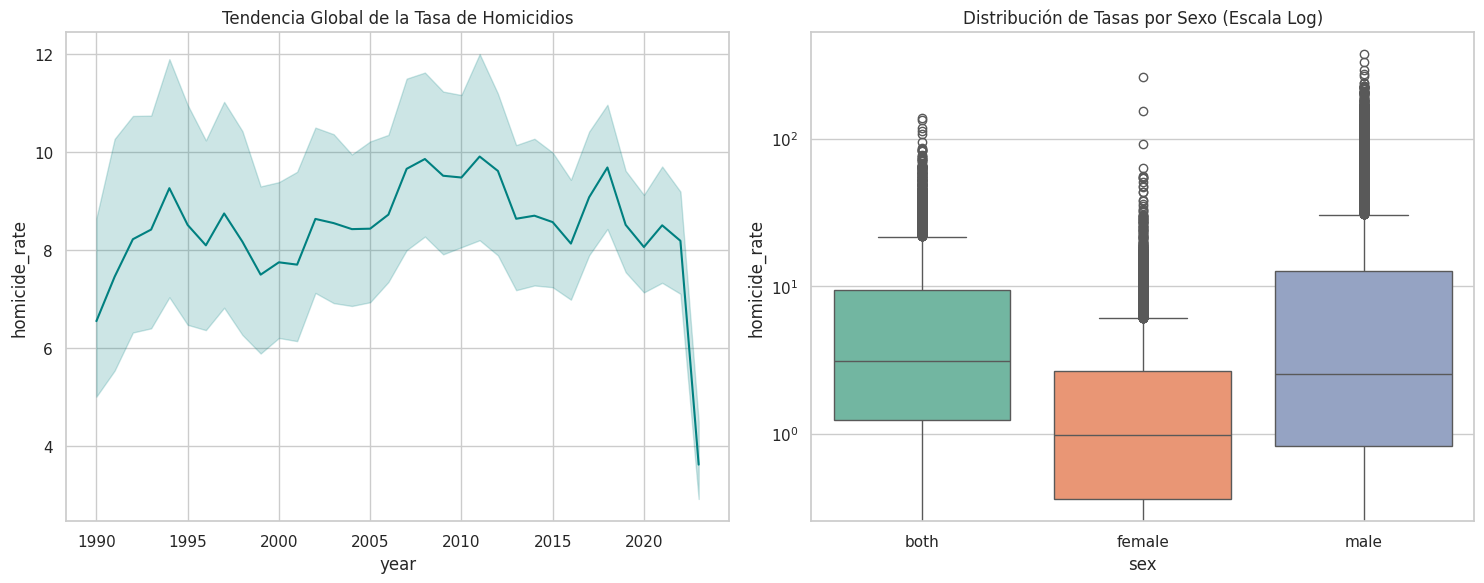

In [18]:
plt.figure(figsize=(15, 6))

# Gráfico 1: Evolución temporal global
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x='year', y='homicide_rate', estimator='mean', color='teal')
plt.title('Tendencia Global de la Tasa de Homicidios')

# Gráfico 2: Comparación por Sexo
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='sex', y='homicide_rate', palette='Set2')
plt.yscale('log') # Usamos escala logarítmica si hay mucha diferencia de valores
plt.title('Distribución de Tasas por Sexo (Escala Log)')

plt.tight_layout()
plt.show()

In [10]:
df.columns

Index(['iso_code', 'country', 'year', 'sex', 'age_group', 'homicide_rate'], dtype='object')